# Wide-Angle Calibration Baseline

Load the wide-angle JSON fixture and calibrate one OpenCV model plus one pinhole spline model. The resulting `opencv_result` and `spline_result` are the baseline objects for uncertainty experiments.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np

import lensboy as lb
from lensboy.analysis import plot_projection_diff

DATASET_PATH = Path("../data/test_datasets/wide_angle_test_3.json")
if not DATASET_PATH.exists():
    DATASET_PATH = Path("data/test_datasets/wide_angle_test_3.json")

MAX_FRAMES: int | None = None

In [2]:
def load_wide_angle_dataset(path: Path, max_frames: int | None = None):
    """Load a wide-angle JSON fixture as Lensboy target points and frames."""
    data = json.loads(path.read_text())

    image_width = int(data["imageDimensions"]["width"])
    image_height = int(data["imageDimensions"]["height"])

    target_ids = [point["id"] for point in data["targetPoints"]]
    target_id_to_index = {target_id: index for index, target_id in enumerate(target_ids)}
    target_points = np.asarray(
        [
            [
                point["positionMm"]["x"],
                point["positionMm"]["y"],
                point["positionMm"]["z"],
            ]
            for point in data["targetPoints"]
        ],
        dtype=np.float64,
    )

    samples = data["samples"]
    if max_frames is not None:
        samples = samples[:max_frames]

    frames: list[lb.Frame] = []
    for sample in samples:
        target_point_indices: list[int] = []
        detected_points: list[list[float]] = []
        for detection in sample["detections"]:
            target_point_indices.append(target_id_to_index[detection["id"]])
            detected_points.append([detection["pixel"]["x"], detection["pixel"]["y"]])

        frames.append(
            lb.Frame(
                target_point_indices=np.asarray(target_point_indices, dtype=np.int32),
                detected_points_in_image=np.asarray(detected_points, dtype=np.float64),
            )
        )

    return target_points, frames, image_height, image_width


target_points, frames, image_height, image_width = load_wide_angle_dataset(
    DATASET_PATH,
    max_frames=MAX_FRAMES,
)

num_detections = sum(len(frame) for frame in frames)
target_points.shape, len(frames), num_detections, (image_width, image_height)

((868, 3), 199, 124756, (3088, 2064))

## OpenCV Baseline

In [3]:
opencv_config = lb.OpenCVConfig(
    image_height=image_height,
    image_width=image_width,
    included_distortion_coefficients=lb.OpenCVConfig.FULL_14,
)

opencv_result = lb.calibrate_camera(
    target_points,
    frames,
    camera_model_config=opencv_config,
)

opencv_metrics = {
    "model": repr(opencv_result.camera_model),
    "sigma_px": opencv_result.residual_sigma_map(),
    "num_detections": opencv_result.num_detections(),
    "num_outliers": opencv_result.num_outliers(),
    "outlier_pct": 100.0 * opencv_result.num_outliers() / opencv_result.num_detections(),
}
opencv_metrics

Computing initial poses with PnP...
Auto-estimated initial stereographic focal length: 1202.1 px
PnP solved 199/199 frames
OpenCV pass 1: 2.6s (mean reproj=0.173px, worst=3.561px)
Outlier filtering: 1340/124756 (1.1%) — re-optimizing...
OpenCV pass 2: 1.1s (mean reproj=0.166px, worst=0.662px)
Outlier filtering: 1398/124756 (1.1%) — re-optimizing...
OpenCV pass 3: 0.5s (mean reproj=0.165px, worst=0.616px)


{'model': 'OpenCV(3088x2064, f=[1351.3, 1351.4], c=[1525.1, 1086.2], 14 distortion coeffs)',
 'sigma_px': 0.12036814862874486,
 'num_detections': 124756,
 'num_outliers': 1398,
 'outlier_pct': 1.1205873865786014}

## Spline Baseline

In [4]:
spline_config = lb.PinholeSplinedConfig(
    image_height=image_height,
    image_width=image_width,
    num_knots_x=30,
    num_knots_y=20,
)

spline_result = lb.calibrate_camera(
    target_points,
    frames,
    camera_model_config=spline_config,
)

spline_metrics = {
    "model": repr(spline_result.camera_model),
    "sigma_px": spline_result.residual_sigma_map(),
    "num_detections": spline_result.num_detections(),
    "num_outliers": spline_result.num_outliers(),
    "outlier_pct": 100.0 * spline_result.num_outliers() / spline_result.num_detections(),
}
spline_metrics

Fitted raw stereographic seed: 0.6s (FOV: 135.5° x 97.9°)
Spline FOV from raw stereographic seed: 135.5° x 97.9°
PnP solved 199/199 frames
Spline pass 1: 9.9s (mean reproj=0.167px, worst=3.550px)
Outlier filtering: 1485/124756 (1.2%) — re-optimizing...
Spline pass 2: 3.6s (mean reproj=0.159px, worst=0.650px)
Outlier filtering: 1534/124756 (1.2%) — re-optimizing...
Spline pass 3: 2.9s (mean reproj=0.159px, worst=0.617px)


{'model': 'PinholeSplined(3088x2064, f=[1164.9, 1180.1], c=[1523.7, 1074.7], knots=30x20, fov=[135.5°, 97.9°])',
 'sigma_px': 0.11470868593408098,
 'num_detections': 124756,
 'num_outliers': 1534,
 'outlier_pct': 1.2296001795504825}

In [5]:
opencv_metrics, spline_metrics

({'model': 'OpenCV(3088x2064, f=[1351.3, 1351.4], c=[1525.1, 1086.2], 14 distortion coeffs)',
  'sigma_px': 0.12036814862874486,
  'num_detections': 124756,
  'num_outliers': 1398,
  'outlier_pct': 1.1205873865786014},
 {'model': 'PinholeSplined(3088x2064, f=[1164.9, 1180.1], c=[1523.7, 1074.7], knots=30x20, fov=[135.5°, 97.9°])',
  'sigma_px': 0.11470868593408098,
  'num_detections': 124756,
  'num_outliers': 1534,
  'outlier_pct': 1.2296001795504825})

## Odd-Even Cross Validation

In [6]:
even_frames = frames[::2]
odd_frames = frames[1::2]

len(even_frames), len(odd_frames)

(100, 99)

### OpenCV Odd-Even

In [7]:
opencv_even_result = lb.calibrate_camera(
    target_points,
    even_frames,
    camera_model_config=opencv_config,
)
opencv_odd_result = lb.calibrate_camera(
    target_points,
    odd_frames,
    camera_model_config=opencv_config,
)

Computing initial poses with PnP...
Auto-estimated initial stereographic focal length: 1202.1 px
PnP solved 100/100 frames
OpenCV pass 1: 1.0s (mean reproj=0.173px, worst=3.558px)
Outlier filtering: 686/61980 (1.1%) — re-optimizing...
OpenCV pass 2: 0.6s (mean reproj=0.165px, worst=0.657px)
Outlier filtering: 716/61980 (1.2%) — re-optimizing...
OpenCV pass 3: 0.2s (mean reproj=0.165px, worst=0.615px)
Computing initial poses with PnP...
Auto-estimated initial stereographic focal length: 1202.1 px
PnP solved 99/99 frames
OpenCV pass 1: 3.2s (mean reproj=0.173px, worst=2.868px)
Outlier filtering: 659/62776 (1.0%) — re-optimizing...
OpenCV pass 2: 0.6s (mean reproj=0.166px, worst=0.646px)
Outlier filtering: 689/62776 (1.1%) — re-optimizing...
OpenCV pass 3: 0.2s (mean reproj=0.166px, worst=0.615px)


Implied rotation: x=0.0277 y=-0.0000 z=-0.0002 deg
Implied translation: [0. 0. 0.]


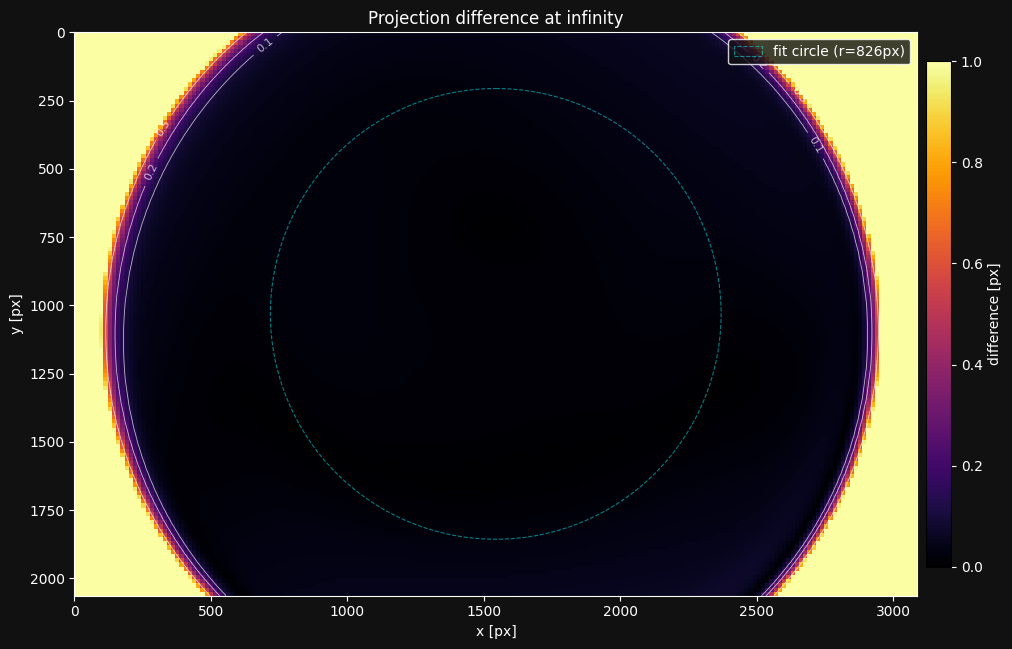

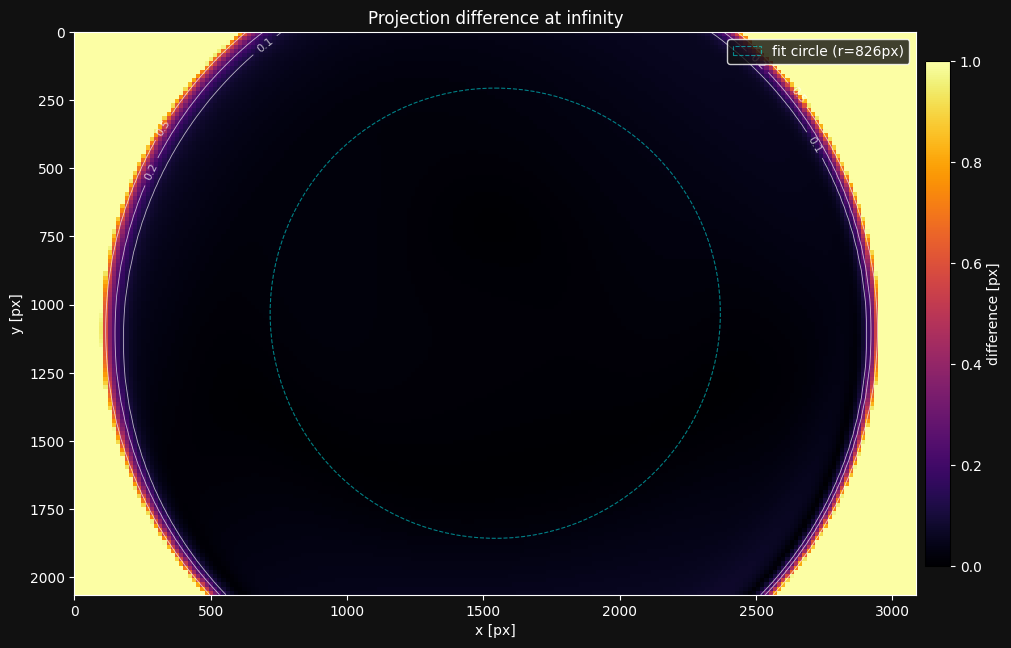

In [8]:
opencv_odd_even_diff_fig = plot_projection_diff(
    opencv_even_result.camera_model,
    opencv_odd_result.camera_model,
    return_figure=True,
    heatmap_max=1.0
)
opencv_odd_even_diff_fig

### Spline Odd-Even

In [9]:
spline_even_result = lb.calibrate_camera(
    target_points,
    even_frames,
    camera_model_config=spline_config,
)
spline_odd_result = lb.calibrate_camera(
    target_points,
    odd_frames,
    camera_model_config=spline_config,
)

Fitted raw stereographic seed: 0.5s (FOV: 135.0° x 98.3°)
Spline FOV from raw stereographic seed: 135.0° x 98.3°
PnP solved 100/100 frames
Spline pass 1: 4.4s (mean reproj=0.167px, worst=3.530px)
Outlier filtering: 739/61980 (1.2%) — re-optimizing...
Spline pass 2: 1.8s (mean reproj=0.159px, worst=0.652px)
Outlier filtering: 772/61980 (1.2%) — re-optimizing...
Spline pass 3: 1.5s (mean reproj=0.159px, worst=0.605px)
Fitted raw stereographic seed: 0.6s (FOV: 136.8° x 98.1°)
Spline FOV from raw stereographic seed: 136.8° x 98.1°
PnP solved 99/99 frames
Spline pass 1: 4.7s (mean reproj=0.166px, worst=2.913px)
Outlier filtering: 739/62776 (1.2%) — re-optimizing...
Spline pass 2: 1.8s (mean reproj=0.159px, worst=0.621px)
Outlier filtering: 762/62776 (1.2%) — re-optimizing...
Spline pass 3: 1.6s (mean reproj=0.159px, worst=0.583px)


Implied rotation: x=0.0456 y=1.1636 z=-0.0120 deg
Implied translation: [0. 0. 0.]


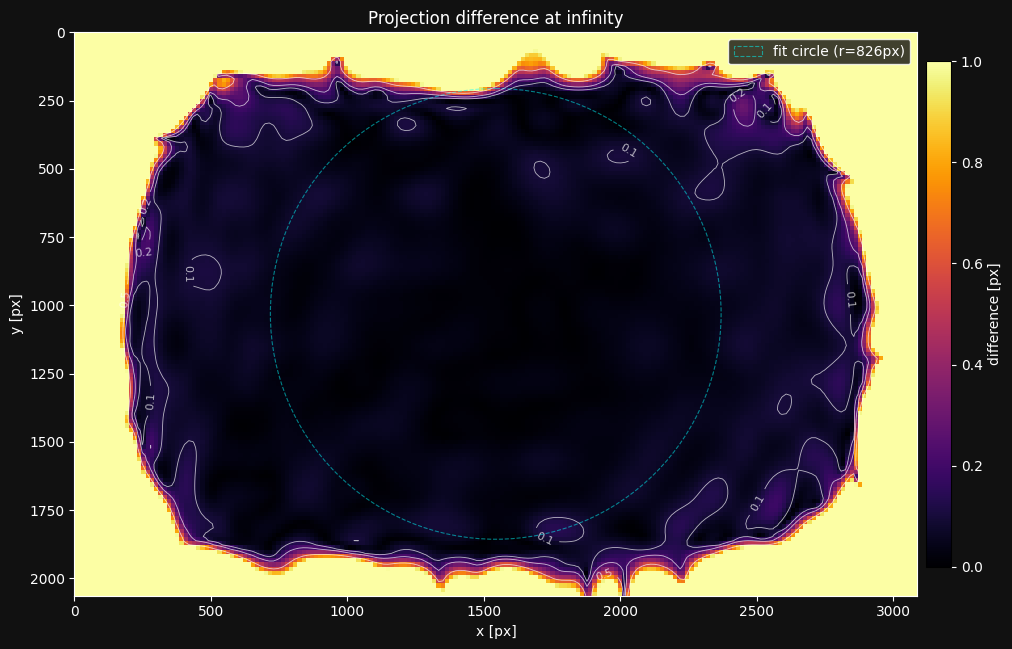

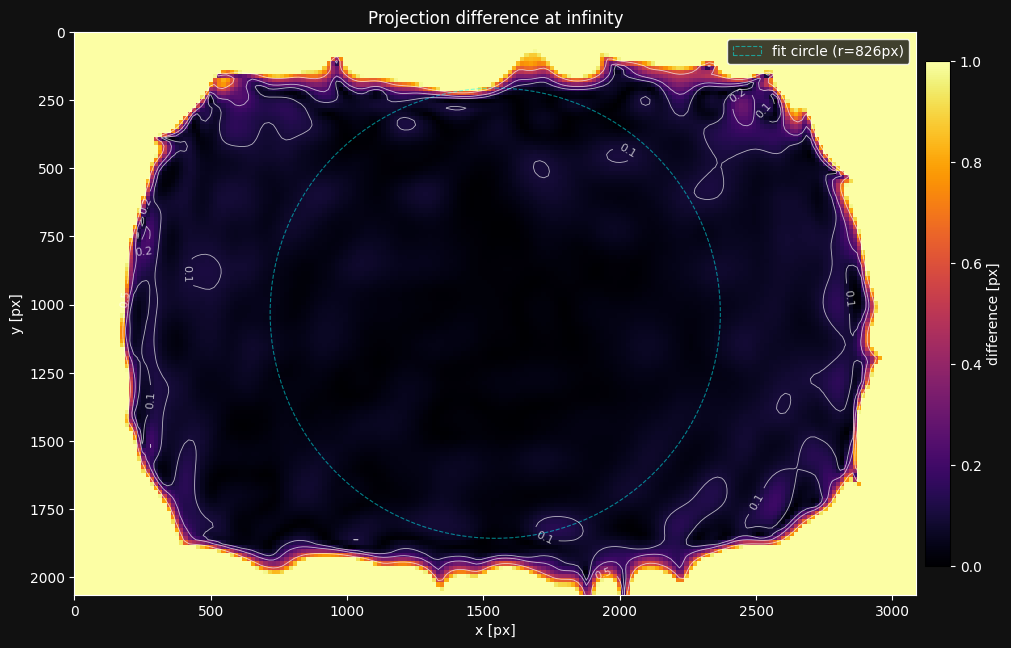

In [10]:
spline_odd_even_diff_fig = plot_projection_diff(
    spline_even_result.camera_model,
    spline_odd_result.camera_model,
    return_figure=True,
    heatmap_max=1.0
)
spline_odd_even_diff_fig

## Projection Uncertainty Maps

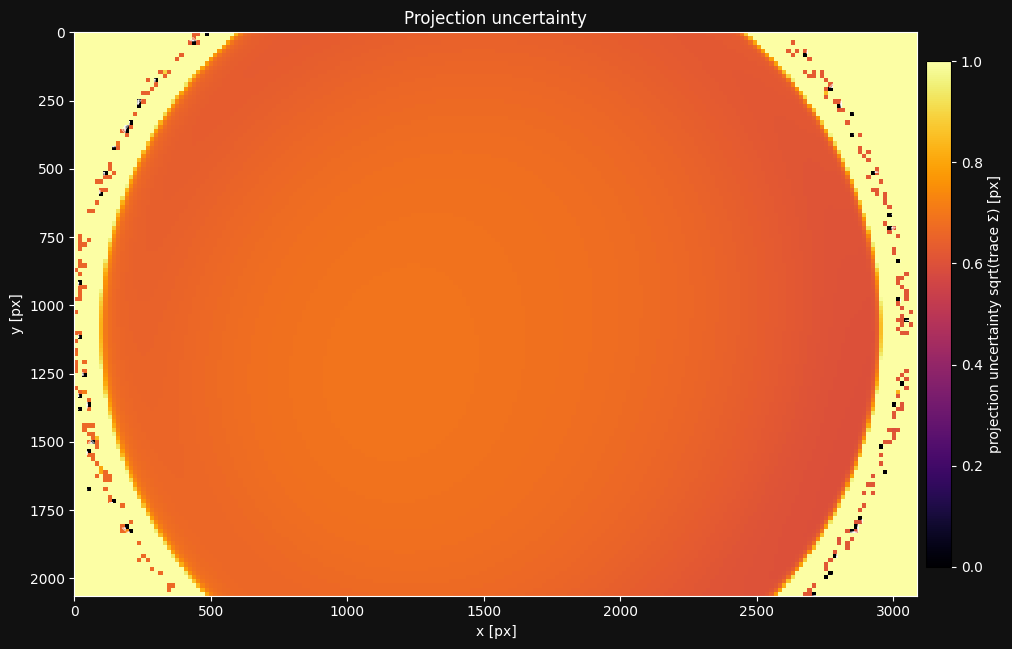

In [16]:
opencv_result.plot_projection_uncertainty(
    heatmap_max=1.0
)

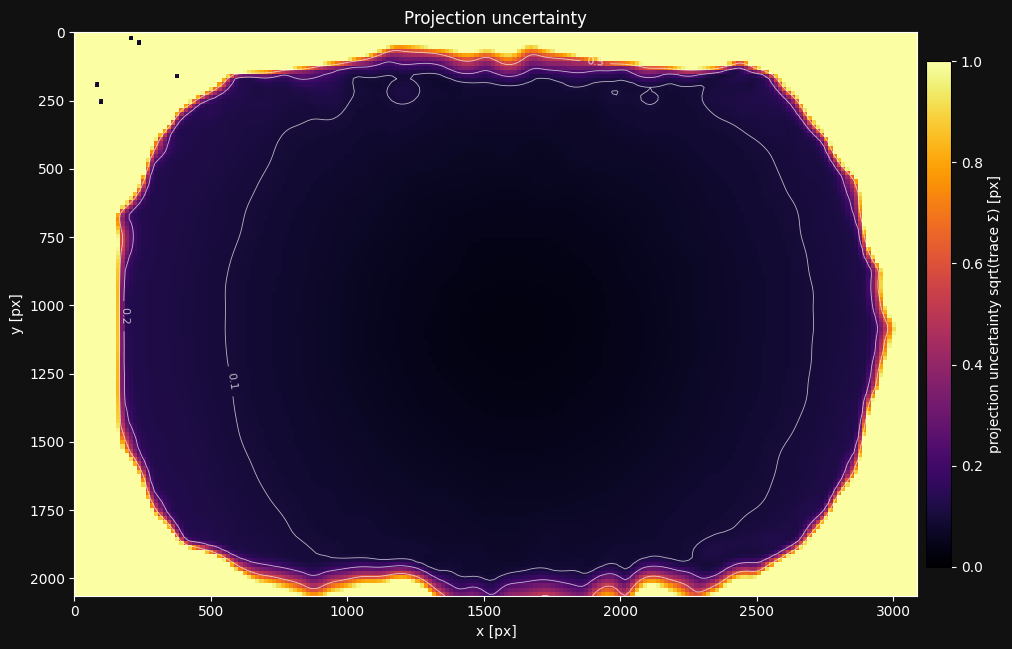

In [15]:
spline_result.plot_projection_uncertainty(
    heatmap_max=1.0
)